In [2]:
import sys
sys.path.append(r'/Users/gabriellebouvier/SIR_Model/src/Particles')

In [3]:
import particles

from sir_PMCMC import ChainBinomialModel
from sir_PMCMC import ScalarStructDist
from sir_PMCMC import custom_mom
import multiprocess as mp
import numpy as np
import pandas as pd
import seaborn as sb
import time
import pickle
import statistics

from particles import distributions as dists
from particles import state_space_models as ssm
from particles.collectors import Moments
from particles import mcmc
from collections import OrderedDict
from particles import collectors as col
from matplotlib import pyplot as plt
from SIR_Model import model, x, y, simulation_df

from statsmodels.graphics.tsaplots import plot_acf


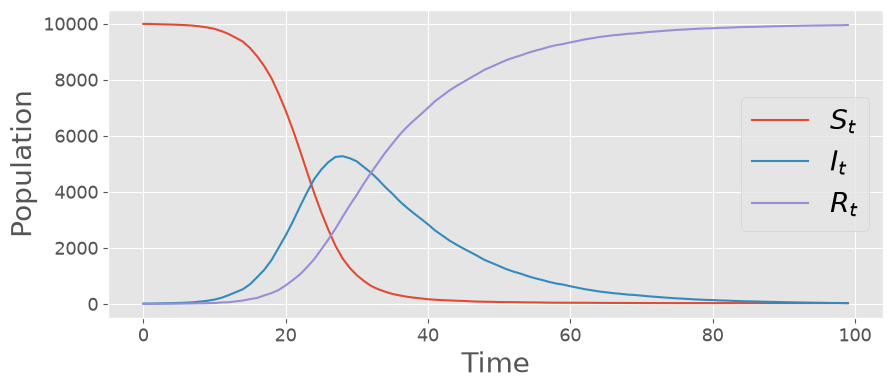

In [4]:
# Plot Epidemic evolution
plt.style.use('ggplot')
plt.figure(figsize=(10,4))
plt.plot(simulation_df['S'], label=r'$S_t$')
plt.plot(simulation_df['I'], label=r'$I_t$')
plt.plot(simulation_df['R'], label=r'$R_t$')

plt.xlabel('Time', fontsize=20)
plt.ylabel('Population', fontsize=20)

plt.tick_params(axis='both', labelsize=13)
plt.legend(fontsize = 20)

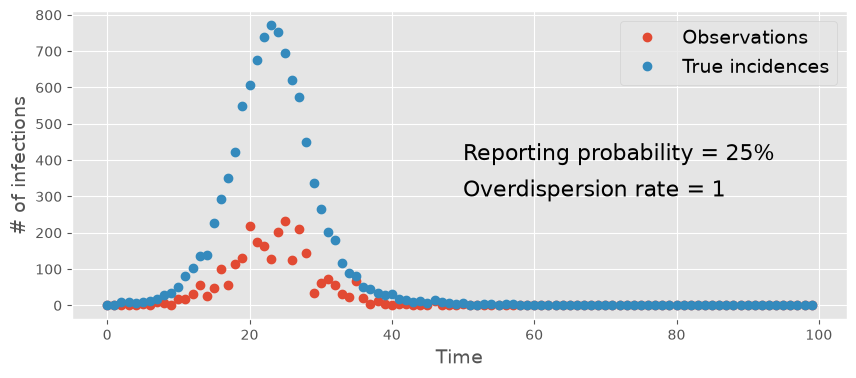

In [5]:
# Plot the observation model
plt.style.use('ggplot')
plt.figure(figsize=(10,4))
plt.plot(y, label='Observations', linestyle='', marker='o')
plt.plot(simulation_df['new_inf'], label='True incidences', linestyle='', marker='o')
plt.xlabel('Time', fontsize=14)
plt.ylabel('# of infections', fontsize=14)
plt.text(50,400,f'Reporting probability = 25%', fontsize = 16)
plt.text(50,300,f'Overdispersion rate = 1', fontsize = 16)
plt.legend(fontsize = 14)
plt.show()

# Open Files

In [12]:
analysis = 'phi'
reporting = '01'

if analysis == 'rho':
    print(f'The following code is for reporting probability (rho) {reporting}, while the overdispersion rate is constant at 5.')
elif analysis == 'phi':
    print(f'The following code is for overdispersion rate (phi) {reporting}, while the reporting probability is constant at 0.25.')

The following code is for overdispersion rate (phi) 01, while the reporting probability is constant at 0.25.


In [13]:
# Open PMCMC files
pmmh_path = f'/Users/gabriellebouvier/SIR_Model/pmmh_{analysis}_{reporting}.pkl'
with open(pmmh_path, 'rb') as output_multi:
    pmmh = pickle.load(output_multi)

## CPU Time

In [14]:
# List and average cpu time

pmmh_cpu = []
for i in pmmh:
    pmmh_cpu.append(i.cpu_time)

print(f"The average cpu time when {analysis} is {reporting} was {np.mean(pmmh_cpu):.2f} seconds.")


The average cpu time when phi is 01 was 190.43 seconds.


## Acceptance Rate

In [15]:
# List and average acceptance rate
pmmh_acc = []
for i in pmmh:
    pmmh_acc.append(i.acc_rate)

print(f"The average acceptance rate when {analysis} is {reporting} was {np.mean(pmmh_acc):.2f}.")

print(pmmh_acc)


The average acceptance rate when phi is 01 was 0.36.
[0.34546909381876373, 0.3712742548509702, 0.35467093418683737, 0.35807161432286455, 0.35707141428285655, 0.3790758151630326, 0.3556711342268454, 0.36387277455491096, 0.36967393478695737, 0.35807161432286455, 0.3566713342668534, 0.3652730546109222, 0.35907181436287255, 0.373874774954991, 0.3756751350270054]


In [16]:
# List of chains
burnin = 1000
pmmh_list = []
for i in pmmh:
    pmmh_list.append(i.chain.theta[burnin:])

In [17]:
np.savez(f"pmmh_{analysis}_{reporting}.npz", arr0 = pmmh_list)

print(f"pmmh_{analysis}_{reporting}.npz file saved")

pmmh_phi_01.npz file saved


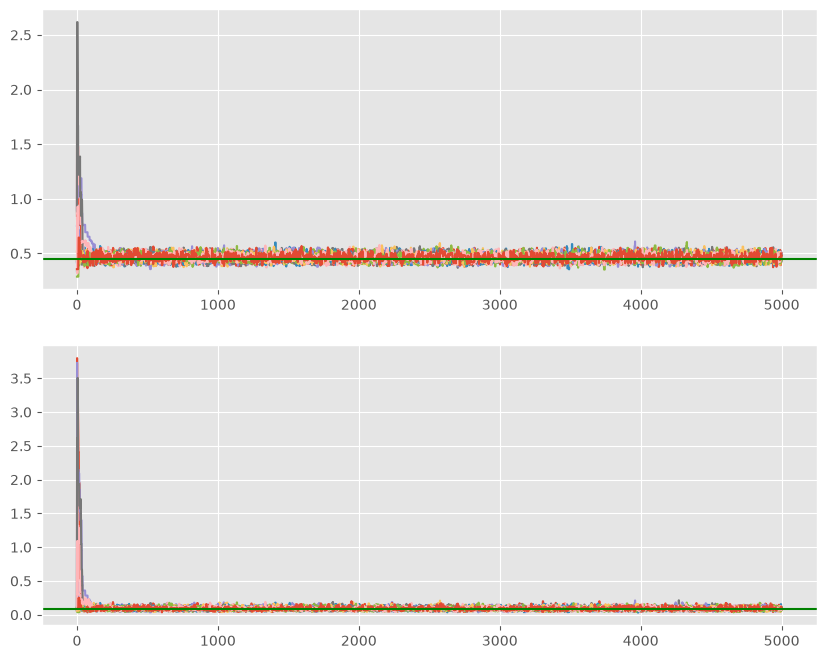

In [18]:
fig, axes = plt.subplots(2,1)
burnin = 1000

for i in range(15):
    axes[0].plot(pmmh[i].chain.theta['beta'])
for i in range(15):
    axes[1].plot(pmmh[i].chain.theta['gamma'])


fig.set_figheight(8)
fig.set_figwidth(10)
axes[0].axhline(y = 0.45, color='green')
axes[1].axhline(y = 0.08, color='green')

In [19]:
# Prior distributions for Parameters
prior_dict = {'beta': dists.Gamma(a = 4.5, b = 10),
              'gamma': dists.Gamma(a = 8, b = 100)}  # Uniform distribution because the prior is uninformative

my_prior = ScalarStructDist(prior_dict)      # need this because 'dict' object has no attribute 'dtype' but StructDist does

Text(0.5, 0, 'gamma')

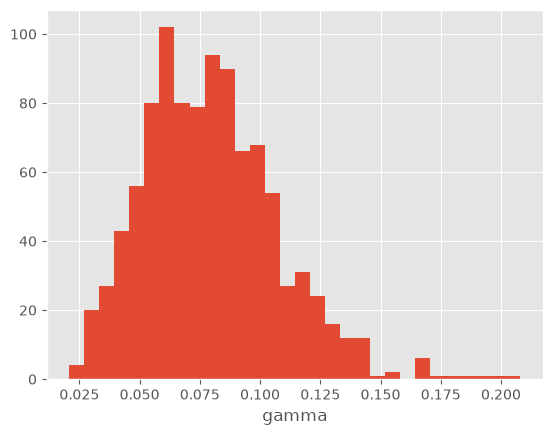

In [20]:
theta = my_prior.rvs(size=1000)  # sample 1000 theta-parameters

plt.style.use('ggplot')
plt.hist(theta['gamma'], 30);
plt.xlabel('gamma')


# Trace Plots

In [21]:
# Open PMCMC files
rho_1_path = f'/Users/gabriellebouvier/SIR_Model/pmmh_rho_1.pkl'
with open(rho_1_path, 'rb') as output_multi:
    rho_1 = pickle.load(output_multi)

rho_5_path = f'/Users/gabriellebouvier/SIR_Model/pmmh_rho_5.pkl'
with open(rho_5_path, 'rb') as output_multi:
    rho_5 = pickle.load(output_multi)

rho_25_path = f'/Users/gabriellebouvier/SIR_Model/pmmh_rho_25.pkl'
with open(rho_25_path, 'rb') as output_multi:
    rho_25 = pickle.load(output_multi)

rho_10_path = f'/Users/gabriellebouvier/SIR_Model/pmmh_rho_10.pkl'
with open(rho_10_path, 'rb') as output_multi:
    rho_10 = pickle.load(output_multi)

rho_05_path = f'/Users/gabriellebouvier/SIR_Model/pmmh_rho_05.pkl'
with open(rho_05_path, 'rb') as output_multi:
    rho_05 = pickle.load(output_multi)

# Open PMCMC files
phi_100_path = f'/Users/gabriellebouvier/SIR_Model/pmmh_phi_100.pkl'
with open(phi_100_path, 'rb') as output_multi:
    phi_100 = pickle.load(output_multi)

phi_50_path = f'/Users/gabriellebouvier/SIR_Model/pmmh_phi_50.pkl'
with open(phi_50_path, 'rb') as output_multi:
    phi_50 = pickle.load(output_multi)

phi_10_path = f'/Users/gabriellebouvier/SIR_Model/pmmh_phi_10.pkl'
with open(phi_10_path, 'rb') as output_multi:
    phi_10 = pickle.load(output_multi)

phi_01_path = f'/Users/gabriellebouvier/SIR_Model/pmmh_phi_01.pkl'
with open(phi_01_path, 'rb') as output_multi:
    phi_01 = pickle.load(output_multi)

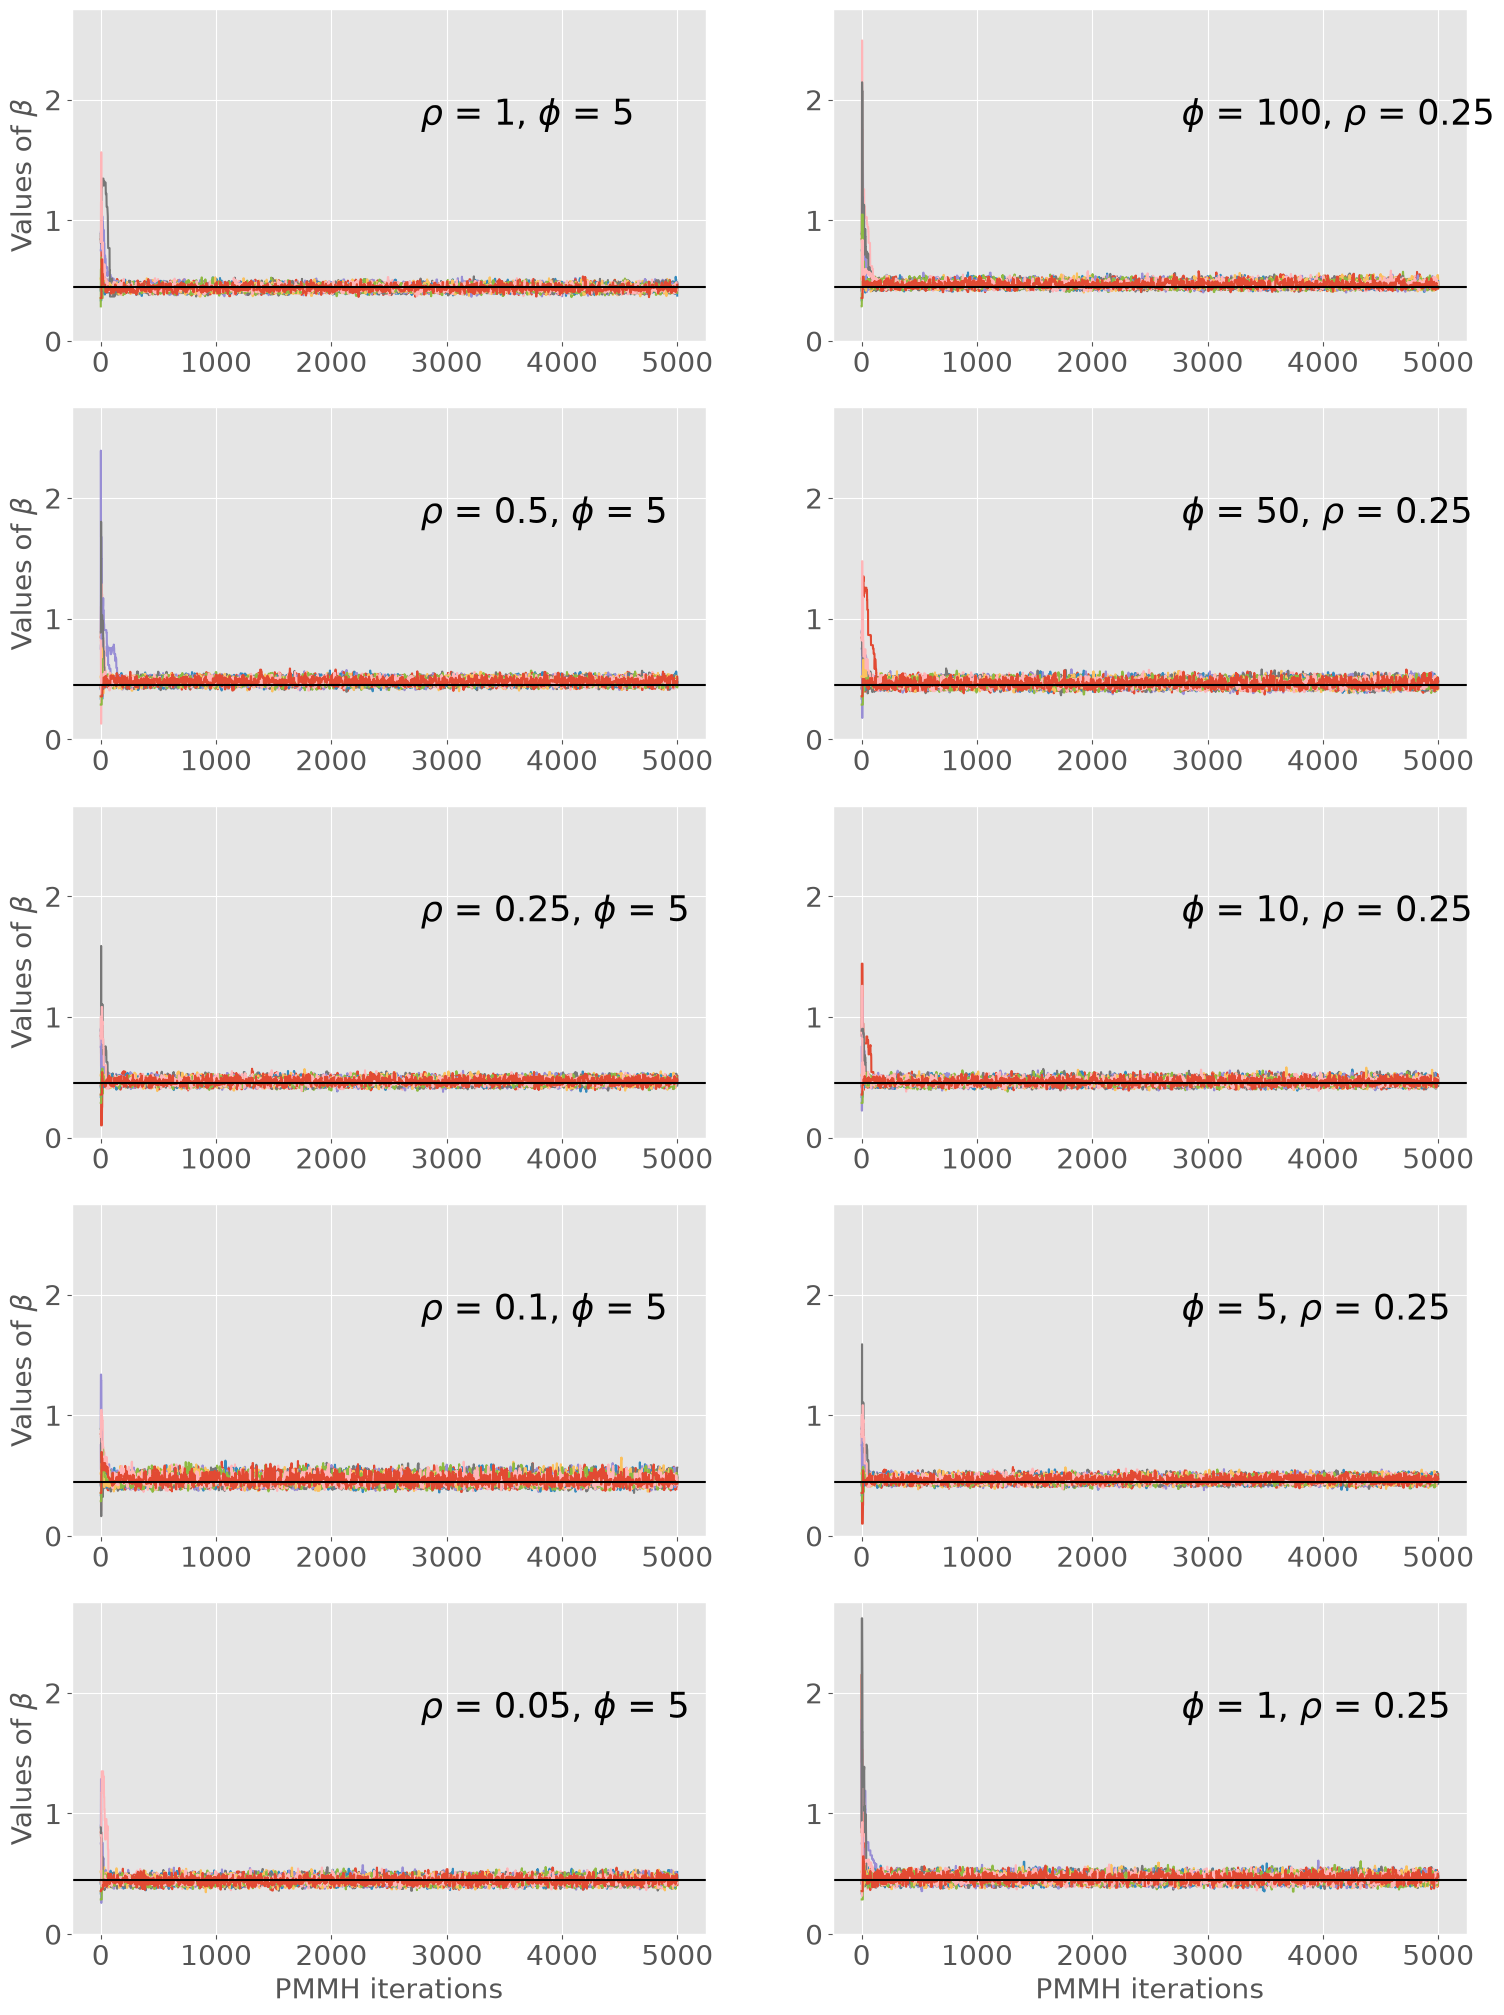

In [53]:
fig, axes = plt.subplots(5,2)
burnin = 1000

for i in range(15):
    axes[0][0].plot(rho_1[i].chain.theta['beta'])
axes[0][0].text(0.55,0.65,rf'$\rho$ = {1}, $\phi$ = 5', transform=axes[0][0].transAxes, fontsize =25)

for i in range(15):
    axes[1][0].plot(rho_5[i].chain.theta['beta'])
axes[1][0].text(0.55,0.65,rf'$\rho$ = {0.50}, $\phi$ = 5', transform=axes[1][0].transAxes, fontsize =25)

for i in range(15):
    axes[2][0].plot(rho_25[i].chain.theta['beta'])
axes[2][0].text(0.55,0.65,rf'$\rho$ = {0.25}, $\phi$ = 5', transform=axes[2][0].transAxes, fontsize =25)

for i in range(15):
    axes[3][0].plot(rho_10[i].chain.theta['beta'])
axes[3][0].text(0.55,0.65,rf'$\rho$ = {0.10}, $\phi$ = 5', transform=axes[3][0].transAxes, fontsize =25)

for i in range(15):
    axes[4][0].plot(rho_05[i].chain.theta['beta'])

axes[4][0].text(0.55,0.65,rf'$\rho$ = {0.05}, $\phi$ = 5', transform=axes[4][0].transAxes, fontsize =25)

for i in range(15):
    axes[0][1].plot(phi_100[i].chain.theta['beta'])

axes[0][1].text(0.55,0.65,rf'$\phi$ = {100}, $\rho$ = 0.25', transform=axes[0][1].transAxes, fontsize =25)

for i in range(15):
    axes[1][1].plot(phi_50[i].chain.theta['beta'])

axes[1][1].text(0.55,0.65,rf'$\phi$ = {50}, $\rho$ = 0.25', transform=axes[1][1].transAxes, fontsize =25)

for i in range(15):
    axes[2][1].plot(phi_10[i].chain.theta['beta'])

axes[2][1].text(0.55,0.65,rf'$\phi$ = {10}, $\rho$ = 0.25', transform=axes[2][1].transAxes, fontsize =25)

for i in range(15):
    axes[3][1].plot(rho_25[i].chain.theta['beta'])
axes[3][1].text(0.55,0.65,rf'$\phi$ = {5}, $\rho$ = 0.25', transform=axes[3][1].transAxes, fontsize =25)

for i in range(15):
    axes[4][1].plot(phi_01[i].chain.theta['beta'])
axes[4][1].text(0.55,0.65,rf'$\phi$ = {1}, $\rho$ = 0.25', transform=axes[4][1].transAxes, fontsize =25)

# Admin
fig.set_figheight(25)
fig.set_figwidth(18)

plt.setp(axes, ylim=(0, 2.75))

axes[0][0].set_ylabel(rf'Values of $\beta$', fontsize = 20)
axes[1][0].set_ylabel(rf'Values of $\beta$', fontsize = 20)
axes[2][0].set_ylabel(rf'Values of $\beta$', fontsize = 20)
axes[3][0].set_ylabel(rf'Values of $\beta$', fontsize = 20)
axes[4][0].set_ylabel(rf'Values of $\beta$', fontsize = 20)
axes[4][0].set_xlabel(rf'PMMH iterations', fontsize = 20)
axes[4][1].set_xlabel(rf'PMMH iterations', fontsize = 20)

for ax in axes.flat:
    ax.tick_params(axis='both', labelsize=20)
    ax.axhline(y = 0.45, color='black')
    


plt.show()

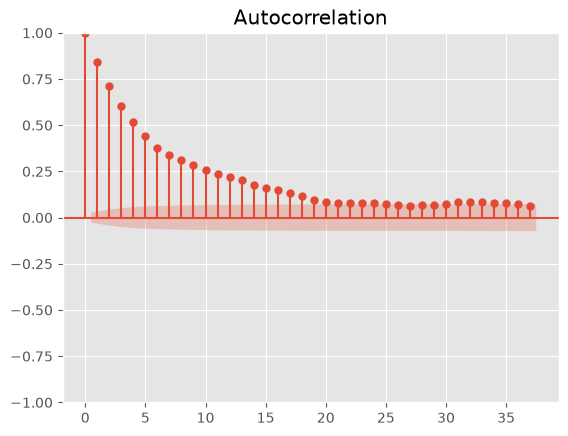

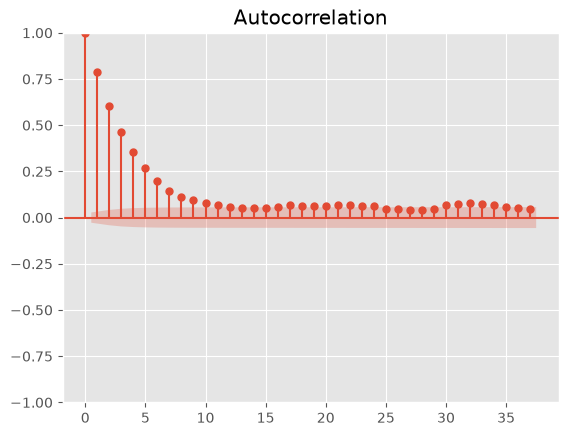

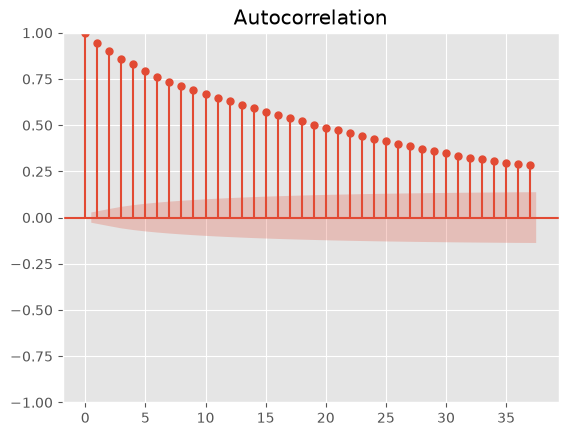

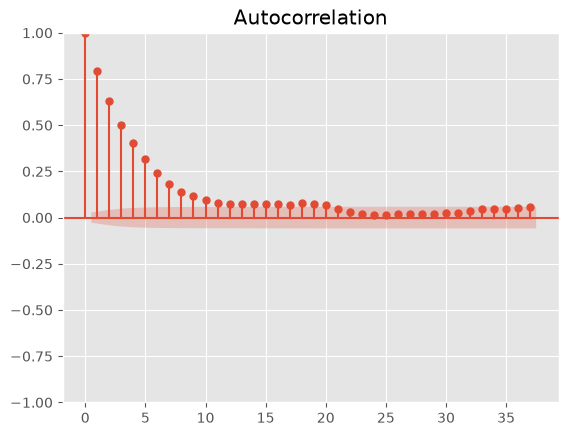

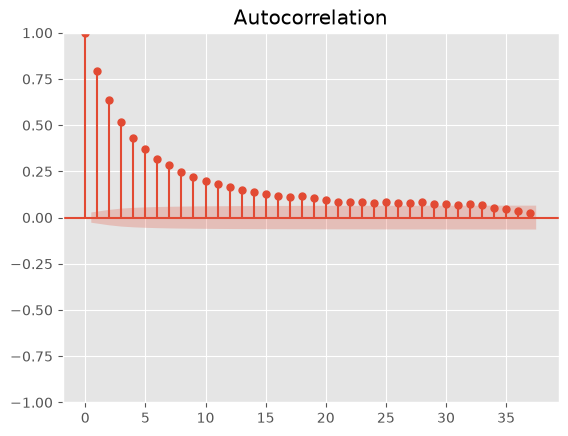

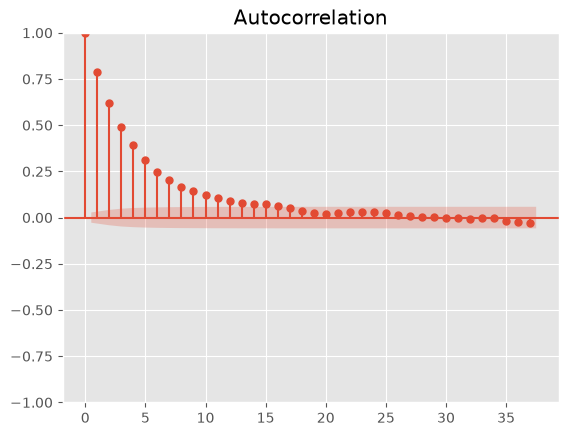

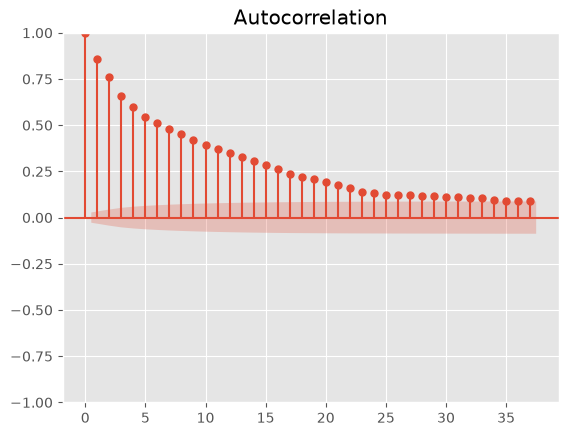

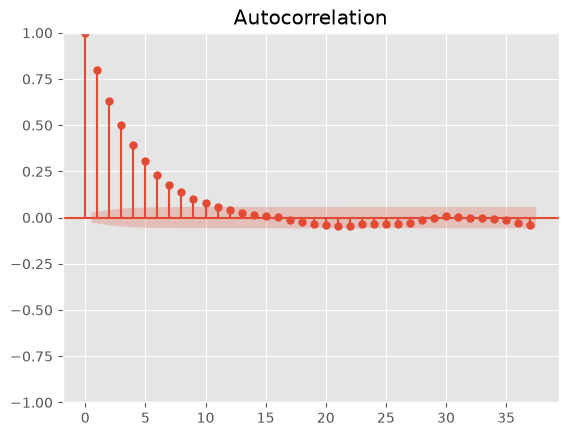

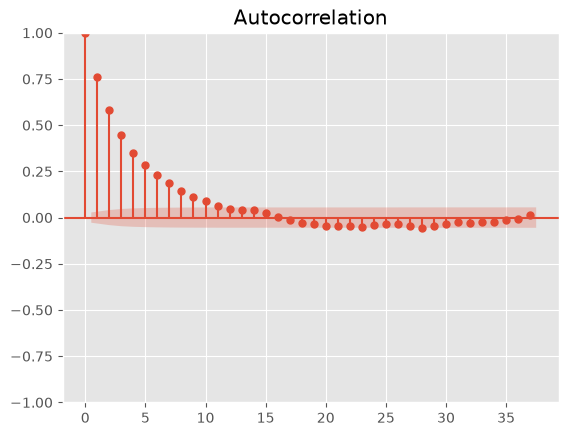

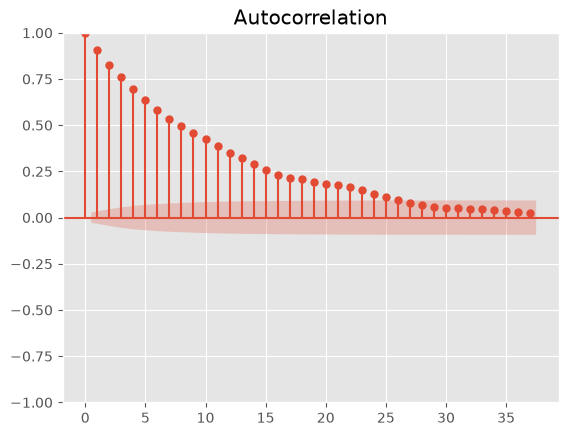

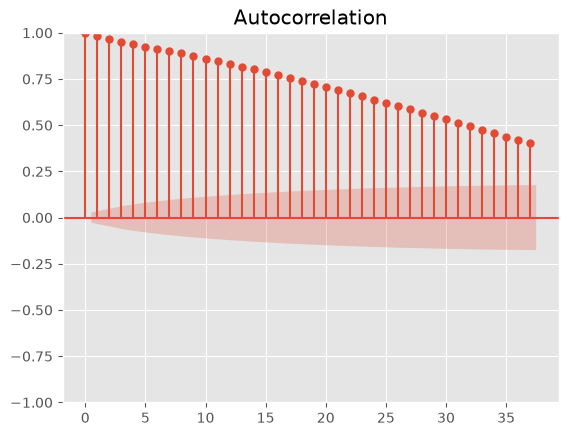

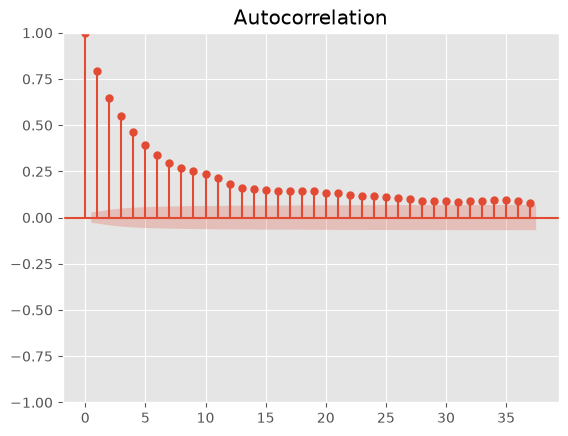

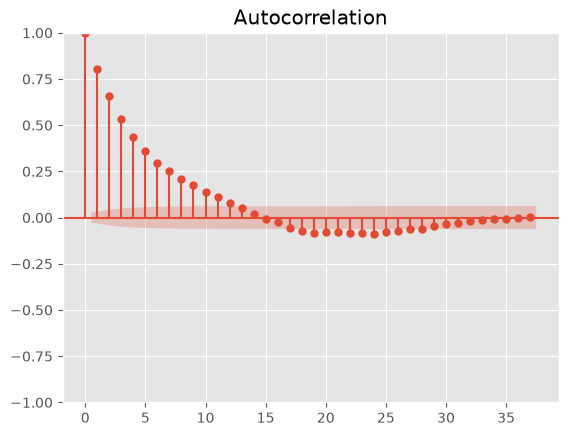

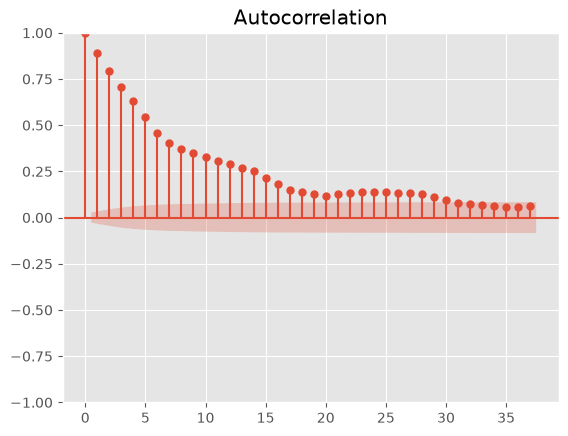

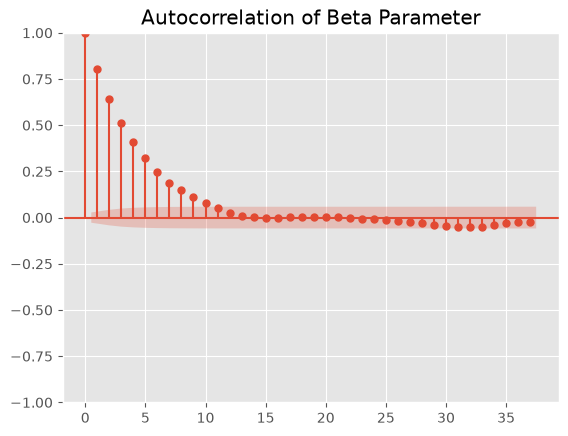

In [23]:
for i in range(15):
    plot_acf(rho_1[i].chain.theta['beta'])
plt.title('Autocorrelation of Beta Parameter')
plt.show()